# Customer Segmentation - Amazing International Airlines (AIAI)

**Group 68** | Data Mining Assignment - Delivery 2 | December 2025

This notebook implements and evaluates clustering algorithms to identify distinct customer segments within AIAI's loyalty program based on the exploratory analysis performed in Delivery 1.

## 1. Data Preparation & Feature Selection

Loading the cleaned dataset from Delivery 1 and selecting features for clustering based on segmentation relevance.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from minisom import MiniSom
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Load the cleaned dataset from Delivery 1
df_raw = pd.read_csv('Data/DM_AIAI_FinalCustomerSegments.csv')
print(f"Raw dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Unique customers: {df_raw['Loyalty#'].nunique():,}")

Raw dataset loaded: 602,532 rows × 40 columns
Unique customers: 16,737


In [3]:
df_raw.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,avg_km_per_flight,avg_points_per_flight,redemption_ratio,points_balance,active_days,months_since_flight,companion_ratio,clv_per_flight,clv_to_salary_ratio,loyalty_tier_numeric,preliminary_segment
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,5,2020-05-01,13,4,25010.0,2501.0,0.0,0.0,1786.428571,178.642857,0.0,2501.0,2509,19,0.285714,274.224286,0.05473,1,Dormant
1,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,4,2020-04-01,0,0,5095.0,509.0,0.0,0.0,5095.000000,509.000000,0.0,509.0,2509,20,0.000000,3839.140000,0.05473,1,Dormant
2,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,2,2020-02-01,3,0,24271.0,2427.0,0.0,0.0,6067.750000,606.750000,0.0,2427.0,2509,22,0.000000,959.785000,0.05473,1,Dormant
3,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,3,2020-03-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2509,21,0.000000,3839.140000,0.05473,1,Dormant
4,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,1,2020-01-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2509,23,0.000000,3839.140000,0.05473,1,Dormant


In [4]:
customer_agg = df_raw.groupby('Loyalty#').agg({
    'Country': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Province or State': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'City': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Education': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Income': 'first',
    'Marital Status': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'LoyaltyStatus': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],

    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',

    'Customer Lifetime Value': 'first',

    'months_since_flight': 'min',
    'active_days': 'max'
}).reset_index()

customer_agg['avg_km_per_flight'] = customer_agg['DistanceKM'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['avg_points_per_flight'] = customer_agg['PointsAccumulated'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['clv_per_flight'] = customer_agg['Customer Lifetime Value'] / customer_agg['NumFlights'].replace(0, 1)

customer_agg['redemption_rate'] = (
    customer_agg['PointsRedeemed'] / customer_agg['PointsAccumulated'].replace(0, 1)
) * 100

df = customer_agg.copy()

In [5]:
# Select features for clustering based on customer segmentation goals

clustering_features = [
    'Customer Lifetime Value',      # Overall customer value
    'NumFlights',                    # Activity level (total flights)
    'DistanceKM',                    # Travel volume (total distance)
    'PointsAccumulated',             # Loyalty engagement (total points)
    'PointsRedeemed',                # Redemption behavior
    'redemption_rate',               # How much they redeem vs accumulate
    'Income',                        # Economic indicator
    'avg_km_per_flight',             # Flight length preference (short vs long haul)
    'avg_points_per_flight',         # Point earning efficiency
    'clv_per_flight',                # Value per flight
    'active_days'                    # Tenure (how long they've been a customer)
]

# Check if all features exist
available_features = [f for f in clustering_features if f in df.columns]

# Create clustering dataset
df_clustering = df[available_features].copy()

print(f"=== CUSTOMER-LEVEL CLUSTERING DATASET ===")
print(f"Total customers: {len(df_clustering):,}")
print(f"Features for clustering: {len(available_features)}\n")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

# Check for missing values
if df_clustering.isnull().sum().sum() > 0:
    print("\nMissing values detected:")
    print(df_clustering.isnull().sum()[df_clustering.isnull().sum() > 0])
    print("\nHandling missing values...")
    df_clustering = df_clustering.fillna(df_clustering.median())
    print("✓ Filled with median values")

=== CUSTOMER-LEVEL CLUSTERING DATASET ===
Total customers: 16,737
Features for clustering: 11

  1. Customer Lifetime Value
  2. NumFlights
  3. DistanceKM
  4. PointsAccumulated
  5. PointsRedeemed
  6. redemption_rate
  7. Income
  8. avg_km_per_flight
  9. avg_points_per_flight
  10. clv_per_flight
  11. active_days


In [6]:
df_clustering.head()

,Customer Lifetime Value,NumFlights,DistanceKM,PointsAccumulated,PointsRedeemed,redemption_rate,Income,avg_km_per_flight,avg_points_per_flight,clv_per_flight,active_days
0,7919.20,231,530230.0,53014.30,20562.8,38.787271,82877.0,2295.367965,229.499134,34.282251,2334
1,2887.74,248,339114.6,33903.96,18760.6,55.334539,0.0,1367.397581,136.709516,11.644113,3582
2,2838.07,217,432030.8,43192.58,4896.0,11.335280,0.0,1990.925346,199.044147,13.078664,2344
3,4170.57,112,364601.7,36453.77,12908.6,35.410878,42837.0,3255.372321,325.480089,37.237232,2702
4,6622.05,187,429630.5,42953.25,10891.4,25.356405,80979.0,2297.489305,229.696524,35.412032,3276


## 2. Data Scaling & Normalization

Applying robust scaling to handle outliers identified in Delivery 1 EDA.

In [7]:
# Apply RobustScaler (better for data with outliers)
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns, index=df_clustering.index)

display(df_scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,16737.0,0.445329,1.383335,-0.782737,-0.362789,0.0,0.637211,15.634932
NumFlights,16737.0,-0.164520,0.607149,-1.225564,-0.699248,0.0,0.300752,1.398496
DistanceKM,16737.0,-0.164735,0.606723,-1.226271,-0.695768,0.0,0.304232,1.415567
PointsAccumulated,16737.0,-0.164694,0.606723,-1.226198,-0.695725,0.0,0.304275,1.415766
PointsRedeemed,16737.0,0.149414,0.642916,-0.478655,-0.478655,0.0,0.521345,3.777619
redemption_rate,16737.0,0.172969,1.156188,-0.511514,-0.511514,0.0,0.488486,78.757841
Income,16737.0,0.057726,0.486735,-0.547279,-0.547279,0.0,0.452721,1.055084
avg_km_per_flight,16737.0,-0.034967,1.642595,-2.775908,-0.494931,0.0,0.505069,42.009159
avg_points_per_flight,16737.0,-0.034928,1.642170,-2.775066,-0.494926,0.0,0.505074,41.999261
clv_per_flight,16737.0,8.813979,35.772683,-0.424431,-0.217260,0.0,0.782740,901.325949


## 3. K-Means Clustering Implementation

### Initial K-Means with k=4

Starting with k=4 clusters based on business understanding and preliminary EDA. This will serve as a baseline before determining the optimal k through silhouette analysis.

In [8]:
optimal_k = 4

# Apply K-Means clustering on full customer dataset
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

print(f"=== K-MEANS CLUSTERING (k={optimal_k}) ===")
print(f"Total customers clustered: {len(df):,}")
print(f"\nCluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Calculate clustering metrics on full dataset
print("\nComputing quality metrics on full customer dataset...")
sil_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
db_score = davies_bouldin_score(df_scaled, df['KMeans_Cluster'])
ch_score = calinski_harabasz_score(df_scaled, df['KMeans_Cluster'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

=== K-MEANS CLUSTERING (k=4) ===
Total customers clustered: 16,737

Cluster Distribution:
KMeans_Cluster
0    15458
1       34
2     1031
3      214
Name: count, dtype: int64

Computing quality metrics on full customer dataset...

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.899 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.496 (lower is better)
Calinski-Harabasz Score: 48859.31 (higher is better)


In [9]:
# Create PCA components for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'], index=df.index)
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']

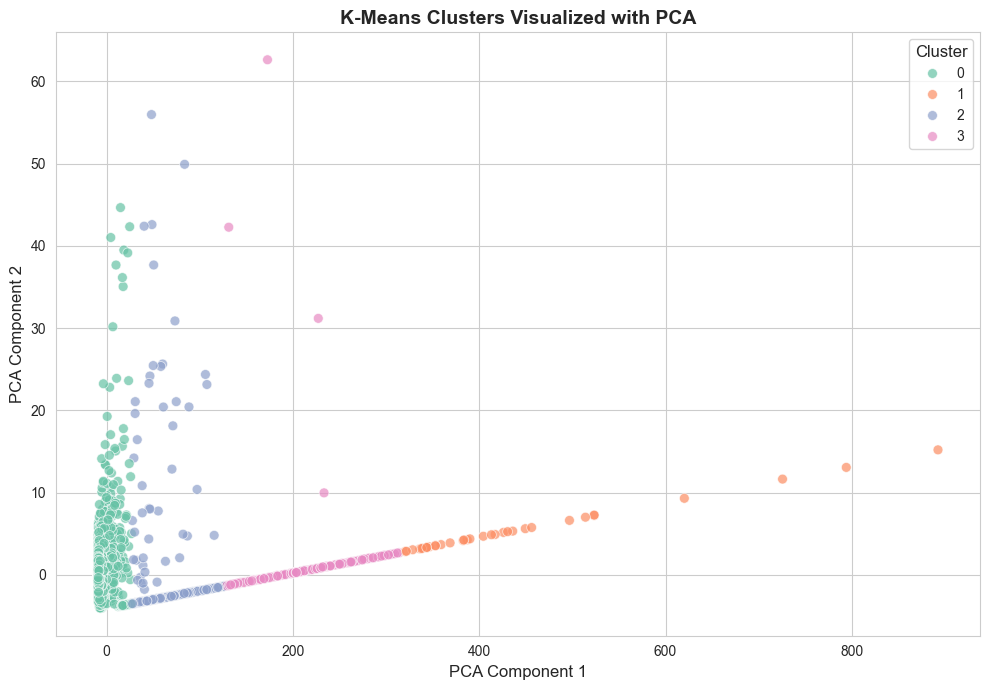

In [10]:
# Plot K-Means Clusters using PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set2', s=50, alpha=0.7)
plt.title('K-Means Clusters Visualized with PCA', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12)
plt.tight_layout()
# plt.savefig(f'{output_dir}/kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Optimal Number of Clusters Determination

Testing different numbers of clusters to find the optimal k using Silhouette Analysis and Dendrogram.

In [11]:
# Silhouette Analysis - Test different numbers of clusters for K-Means and Hierarchical
k_range = range(2, 11)
kmeans_silhouette = []
hierarchical_silhouette = []

print(f"Computing optimal k using all {len(df_scaled):,} customers...")

for k in k_range:
    # K-Means
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans_temp.fit_predict(df_scaled)
    kmeans_silhouette.append(silhouette_score(df_scaled, kmeans_labels))
    
    # Hierarchical
    hierarchical_temp = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hierarchical_labels = hierarchical_temp.fit_predict(df_scaled)
    hierarchical_silhouette.append(silhouette_score(df_scaled, hierarchical_labels))
    
    print(f"  k={k} completed")

# Find optimal k for K-Means and Hierarchical
optimal_k_kmeans = k_range[np.argmax(kmeans_silhouette)]
optimal_k_hierarchical = k_range[np.argmax(hierarchical_silhouette)]

print("\n=== SILHOUETTE SCORES BY NUMBER OF CLUSTERS ===")
print("\nK-Means:")
for k, score in zip(k_range, kmeans_silhouette):
    print(f"  k={k}: {score:.4f}")

print("\nHierarchical (Ward):")
for k, score in zip(k_range, hierarchical_silhouette):
    print(f"  k={k}: {score:.4f}")

print(f"\n=== OPTIMAL NUMBER OF CLUSTERS ===")
print(f"K-Means: k={optimal_k_kmeans} (Silhouette: {max(kmeans_silhouette):.4f})")
print(f"Hierarchical: k={optimal_k_hierarchical} (Silhouette: {max(hierarchical_silhouette):.4f})")

# DBSCAN parameter optimization (eps)
print(f"\n{'='*60}")
print("DBSCAN - Optimizing eps parameter...")
eps_range = np.arange(0.5, 3.0, 0.25)
dbscan_results = []

for eps in eps_range:
    dbscan_temp = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels = dbscan_temp.fit_predict(df_scaled)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    if n_clusters > 1 and n_noise < len(df_scaled) * 0.5:  # Valid clustering
        sil_score = silhouette_score(df_scaled, dbscan_labels)
        dbscan_results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil_score})
        print(f"  eps={eps:.2f}: clusters={n_clusters}, noise={n_noise}, silhouette={sil_score:.4f}")

# Select best eps for DBSCAN
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x['silhouette'])
    optimal_eps = best_dbscan['eps']
    optimal_dbscan_k = best_dbscan['n_clusters']
    print(f"\nOptimal DBSCAN: eps={optimal_eps:.2f}, clusters={optimal_dbscan_k}, silhouette={best_dbscan['silhouette']:.4f}")
else:
    optimal_eps = 1.0
    optimal_dbscan_k = 0
    print("\nWarning: DBSCAN did not find optimal parameters")

# SOM parameter optimization (grid size)
print(f"\n{'='*60}")
print("SOM - Testing different grid sizes...")
som_results = []
som_grid_sizes = [(3, 3), (4, 3), (4, 4), (5, 4), (5, 5)]

for grid_x, grid_y in som_grid_sizes:
    som_temp = MiniSom(grid_x, grid_y, df_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
    som_temp.random_weights_init(df_scaled.values)
    som_temp.train_random(df_scaled.values, 1000)
    
    # Map each customer to their BMU and assign cluster labels
    som_labels = np.array([som_temp.winner(x)[0] * grid_y + som_temp.winner(x)[1] for x in df_scaled.values])
    n_clusters = len(set(som_labels))
    
    if n_clusters > 1:
        sil_score = silhouette_score(df_scaled, som_labels)
        som_results.append({'grid': (grid_x, grid_y), 'n_clusters': n_clusters, 'silhouette': sil_score})
        print(f"  Grid {grid_x}x{grid_y}: clusters={n_clusters}, silhouette={sil_score:.4f}")

# Select best grid for SOM
if som_results:
    best_som = max(som_results, key=lambda x: x['silhouette'])
    optimal_som_grid = best_som['grid']
    optimal_som_k = best_som['n_clusters']
    print(f"\nOptimal SOM: grid={optimal_som_grid}, clusters={optimal_som_k}, silhouette={best_som['silhouette']:.4f}")
else:
    optimal_som_grid = (4, 4)
    optimal_som_k = 0
    print("\nWarning: SOM did not find optimal parameters")

Computing optimal k using all 16,737 customers...
  k=2 completed
  k=3 completed
  k=4 completed
  k=5 completed
  k=6 completed
  k=7 completed
  k=8 completed
  k=9 completed
  k=10 completed

=== SILHOUETTE SCORES BY NUMBER OF CLUSTERS ===

K-Means:
  k=2: 0.9128
  k=3: 0.9025
  k=4: 0.8994
  k=5: 0.8952
  k=6: 0.8781
  k=7: 0.8766
  k=8: 0.8452
  k=9: 0.8456
  k=10: 0.8449

Hierarchical (Ward):
  k=2: 0.9273
  k=3: 0.8924
  k=4: 0.8950
  k=5: 0.8944
  k=6: 0.8946
  k=7: 0.8790
  k=8: 0.8176
  k=9: 0.8173
  k=10: 0.8175

=== OPTIMAL NUMBER OF CLUSTERS ===
K-Means: k=2 (Silhouette: 0.9128)
Hierarchical: k=2 (Silhouette: 0.9273)

DBSCAN - Optimizing eps parameter...
  eps=0.50: clusters=110, noise=6794, silhouette=-0.5560
  eps=0.75: clusters=46, noise=2617, silhouette=0.0088
  eps=1.00: clusters=31, noise=1326, silhouette=0.2095
  eps=1.25: clusters=19, noise=863, silhouette=0.3915
  eps=1.50: clusters=22, noise=622, silhouette=0.3896
  eps=1.75: clusters=16, noise=481, silhouette=0

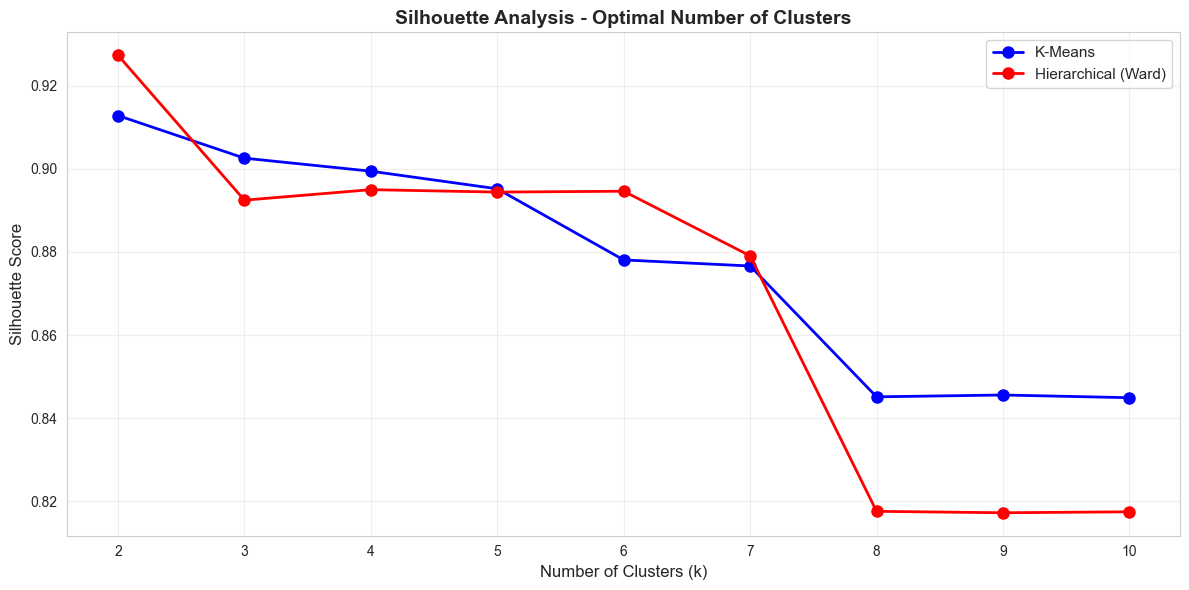

In [12]:
# Plot Silhouette Scores for K-Means and Hierarchical
plt.figure(figsize=(12, 6))
plt.plot(k_range, kmeans_silhouette, 'bo-', linewidth=2, markersize=8, label='K-Means')
plt.plot(k_range, hierarchical_silhouette, 'ro-', linewidth=2, markersize=8, label='Hierarchical (Ward)')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis - Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/optimal_k_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

### Optimal Parameter Analysis Results

The analysis above determines optimal parameters for all four clustering algorithms:
- **K-Means & Hierarchical**: Optimal k based on highest silhouette score
- **DBSCAN**: Optimal eps parameter based on silhouette score and cluster validity
- **SOM**: Optimal grid size based on silhouette score and cluster formation

### 4.1. Re-run K-Means with Optimal K

Applying K-Means clustering using the optimal k determined from the silhouette analysis above.

In [13]:
# Re-run K-Means clustering with optimal k from silhouette analysis
kmeans_optimal = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10, max_iter=300)
df['KMeans_Cluster_Optimal'] = kmeans_optimal.fit_predict(df_scaled)

print(f"=== K-MEANS CLUSTERING WITH OPTIMAL K (k={optimal_k_kmeans}) ===")
print(f"\nCluster Distribution:")
print(df['KMeans_Cluster_Optimal'].value_counts().sort_index())

# Calculate clustering metrics
sil_score_opt = silhouette_score(df_scaled, df['KMeans_Cluster_Optimal'])
db_score_opt = davies_bouldin_score(df_scaled, df['KMeans_Cluster_Optimal'])
ch_score_opt = calinski_harabasz_score(df_scaled, df['KMeans_Cluster_Optimal'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score_opt:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score_opt:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score_opt:.2f} (higher is better)")

# Prepare data for visualization
pca_opt = PCA(n_components=2, random_state=42)
pca_components_opt = pca_opt.fit_transform(df_scaled)
df_pca_opt = pd.DataFrame(data=pca_components_opt, columns=['PCA1', 'PCA2'], index=df.index)
df_pca_opt['KMeans_Cluster'] = df['KMeans_Cluster_Optimal']

# Update the main cluster column to use optimal k results
df['KMeans_Cluster'] = df['KMeans_Cluster_Optimal']

=== K-MEANS CLUSTERING WITH OPTIMAL K (k=2) ===

Cluster Distribution:
KMeans_Cluster_Optimal
0    16096
1      641
Name: count, dtype: int64

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.913 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.503 (lower is better)
Calinski-Harabasz Score: 26856.74 (higher is better)


## 5. Agglomerative Hierarchical Clustering

Applying Hierarchical Clustering with Ward linkage using the optimal k determined from silhouette analysis. This will be compared with K-Means to select the best-performing algorithm.

In [14]:
# Apply Agglomerative Hierarchical Clustering with Ward linkage using optimal k
hierarchical = AgglomerativeClustering(n_clusters=optimal_k_hierarchical, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical.fit_predict(df_scaled)

print(f"=== AGGLOMERATIVE HIERARCHICAL CLUSTERING (k={optimal_k_hierarchical}, Ward Linkage) ===")
print(f"\nCluster Distribution:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

# Calculate clustering metrics for Hierarchical
sil_score_hier = silhouette_score(df_scaled, df['Hierarchical_Cluster'])
db_score_hier = davies_bouldin_score(df_scaled, df['Hierarchical_Cluster'])
ch_score_hier = calinski_harabasz_score(df_scaled, df['Hierarchical_Cluster'])

print(f"\n=== CLUSTERING QUALITY METRICS ===")
print(f"Silhouette Score: {sil_score_hier:.3f} (higher is better, range: -1 to 1)")
print(f"Davies-Bouldin Index: {db_score_hier:.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {ch_score_hier:.2f} (higher is better)")

=== AGGLOMERATIVE HIERARCHICAL CLUSTERING (k=2, Ward Linkage) ===

Cluster Distribution:
Hierarchical_Cluster
0    16422
1      315
Name: count, dtype: int64

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.927 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.410 (lower is better)
Calinski-Harabasz Score: 26531.93 (higher is better)


In [15]:
# Prepare data for hierarchical clustering visualization
df_pca['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

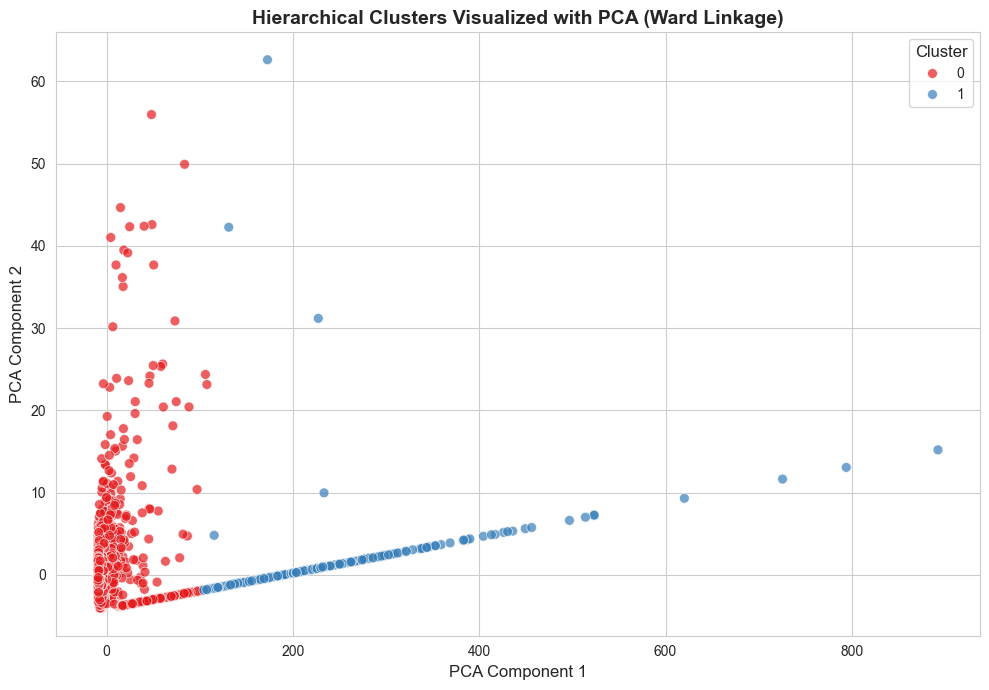

In [16]:
# Plot Hierarchical Clusters using PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='Set1', s=50, alpha=0.7)
plt.title('Hierarchical Clusters Visualized with PCA (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/hierarchical_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.1. DBSCAN (Density-Based Clustering)

Applying DBSCAN clustering with optimized eps parameter. DBSCAN identifies clusters based on density and can detect outliers as noise points.

In [17]:
# Apply DBSCAN clustering with optimal eps
dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise_dbscan = list(df['DBSCAN_Cluster']).count(-1)

print(f"=== DBSCAN CLUSTERING (eps={optimal_eps:.2f}) ===")
print(f"\nNumber of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan} ({n_noise_dbscan/len(df)*100:.1f}%)")
print(f"\nCluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# Calculate clustering metrics for DBSCAN (excluding noise points)
if n_clusters_dbscan > 1:
    mask_dbscan = df['DBSCAN_Cluster'] != -1
    sil_score_dbscan = silhouette_score(df_scaled[mask_dbscan], df.loc[mask_dbscan, 'DBSCAN_Cluster'])
    db_score_dbscan = davies_bouldin_score(df_scaled[mask_dbscan], df.loc[mask_dbscan, 'DBSCAN_Cluster'])
    ch_score_dbscan = calinski_harabasz_score(df_scaled[mask_dbscan], df.loc[mask_dbscan, 'DBSCAN_Cluster'])
    
    print(f"\n=== CLUSTERING QUALITY METRICS (excluding noise) ===")
    print(f"Silhouette Score: {sil_score_dbscan:.3f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Index: {db_score_dbscan:.3f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score_dbscan:.2f} (higher is better)")
else:
    sil_score_dbscan = 0
    db_score_dbscan = 999
    ch_score_dbscan = 0
    print("\nWarning: DBSCAN found less than 2 clusters")

=== DBSCAN CLUSTERING (eps=2.50) ===

Number of clusters: 11
Number of noise points: 250 (1.5%)

Cluster Distribution:
DBSCAN_Cluster
-1       250
 0     15070
 1      1295
 2        20
 3         7
 4         6
 5        53
 6         5
 7        11
 8         9
 9         5
 10        6
Name: count, dtype: int64

=== CLUSTERING QUALITY METRICS (excluding noise) ===
Silhouette Score: 0.890 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 0.380 (lower is better)
Calinski-Harabasz Score: 11947.01 (higher is better)


In [19]:
# Prepare data for DBSCAN visualization
df_pca['DBSCAN_Cluster'] = df['DBSCAN_Cluster']

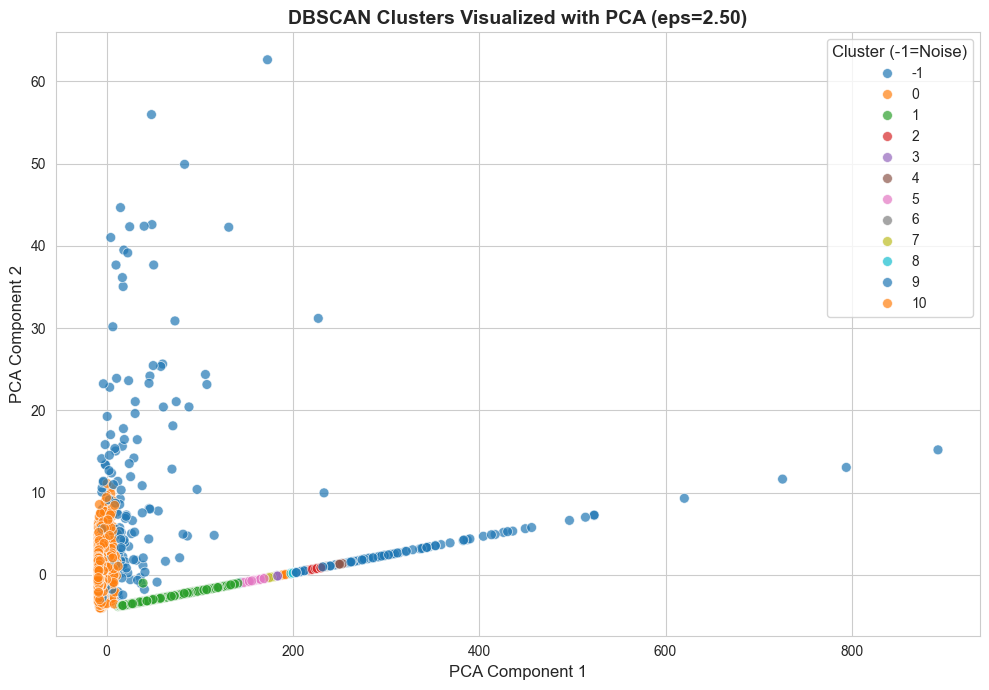

In [20]:
# Plot DBSCAN Clusters using PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10', s=50, alpha=0.7)
plt.title(f'DBSCAN Clusters Visualized with PCA (eps={optimal_eps:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster (-1=Noise)', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/dbscan_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.2. Self-Organizing Maps (SOM)

Applying SOM clustering with optimized grid size. SOM creates a topology-preserving mapping of high-dimensional data onto a 2D grid.

In [21]:
# Apply SOM clustering with optimal grid size
som_x, som_y = optimal_som_grid
som = MiniSom(som_x, som_y, df_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(df_scaled.values)
som.train_random(df_scaled.values, 1000)

# Map each customer to their Best Matching Unit (BMU)
df['SOM_Cluster'] = [som.winner(x)[0] * som_y + som.winner(x)[1] for x in df_scaled.values]

n_clusters_som = len(set(df['SOM_Cluster']))

print(f"=== SELF-ORGANIZING MAP CLUSTERING (Grid: {som_x}x{som_y}) ===")
print(f"\nNumber of clusters formed: {n_clusters_som}")
print(f"\nCluster Distribution:")
print(df['SOM_Cluster'].value_counts().sort_index())

# Calculate clustering metrics for SOM
if n_clusters_som > 1:
    sil_score_som = silhouette_score(df_scaled, df['SOM_Cluster'])
    db_score_som = davies_bouldin_score(df_scaled, df['SOM_Cluster'])
    ch_score_som = calinski_harabasz_score(df_scaled, df['SOM_Cluster'])
    
    print(f"\n=== CLUSTERING QUALITY METRICS ===")
    print(f"Silhouette Score: {sil_score_som:.3f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Index: {db_score_som:.3f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score_som:.2f} (higher is better)")
else:
    sil_score_som = 0
    db_score_som = 999
    ch_score_som = 0
    print("\nWarning: SOM found less than 2 clusters")

=== SELF-ORGANIZING MAP CLUSTERING (Grid: 3x3) ===

Number of clusters formed: 9

Cluster Distribution:
SOM_Cluster
0     279
1     537
2     529
3     408
4     258
5    3080
6     394
7    2029
8    9223
Name: count, dtype: int64

=== CLUSTERING QUALITY METRICS ===
Silhouette Score: 0.271 (higher is better, range: -1 to 1)
Davies-Bouldin Index: 1.075 (lower is better)
Calinski-Harabasz Score: 10864.96 (higher is better)


In [22]:
# Prepare data for SOM visualization
df_pca['SOM_Cluster'] = df['SOM_Cluster']

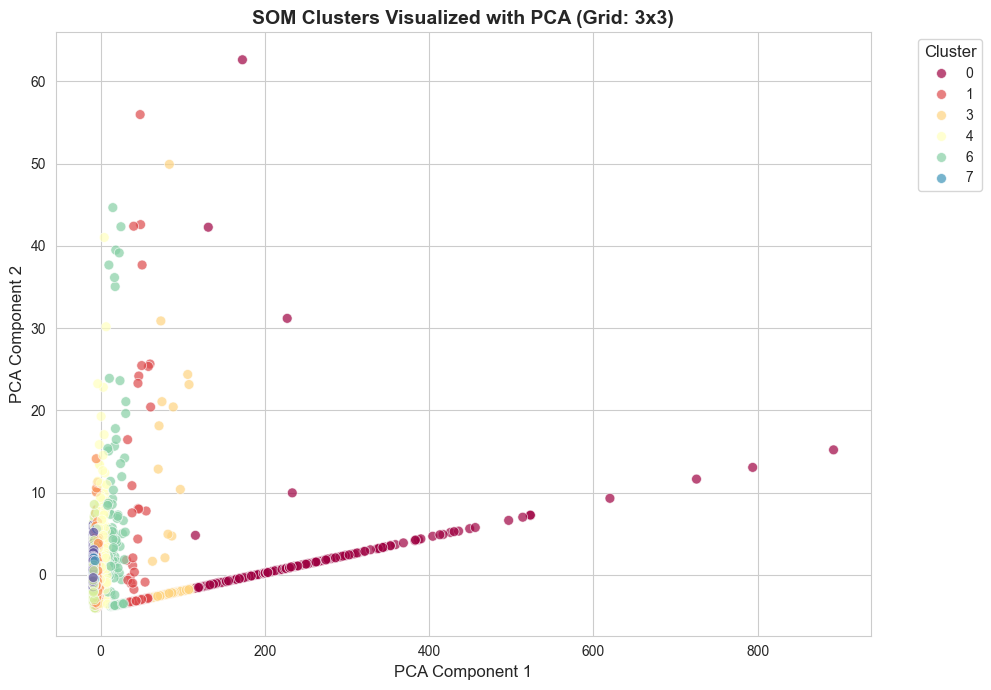

In [23]:
# Plot SOM Clusters using PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='SOM_Cluster', palette='Spectral', s=50, alpha=0.7)
plt.title(f'SOM Clusters Visualized with PCA (Grid: {som_x}x{som_y})', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/som_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Algorithm Comparison & Selection

Comparing all four clustering algorithms using multiple metrics to select the best-performing approach for customer segmentation.

### Algorithm Selection Summary

The comparison above evaluates all four algorithms using three complementary metrics:
- **Silhouette Score**: Measures how well-separated clusters are (higher = better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower = better)  
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance (higher = better)

The best algorithm based on majority voting across metrics is selected for the final segmentation below.

In [24]:
# Compare clustering metrics
comparison_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN', 'SOM'],
    'Clusters': [optimal_k_kmeans, optimal_k_hierarchical, n_clusters_dbscan, n_clusters_som],
    'Silhouette Score': [sil_score_opt, sil_score_hier, sil_score_dbscan, sil_score_som],
    'Davies-Bouldin Index': [db_score_opt, db_score_hier, db_score_dbscan, db_score_som],
    'Calinski-Harabasz Score': [ch_score_opt, ch_score_hier, ch_score_dbscan, ch_score_som]
})

print("=== ALGORITHM COMPARISON ===")
display(comparison_df)

# Select best algorithm based on metrics
best_silhouette = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Algorithm']
best_db = comparison_df.loc[comparison_df['Davies-Bouldin Index'].idxmin(), 'Algorithm']
best_ch = comparison_df.loc[comparison_df['Calinski-Harabasz Score'].idxmax(), 'Algorithm']

print("\n=== BEST ALGORITHM BY METRIC ===")
print(f"Highest Silhouette Score: {best_silhouette}")
print(f"Lowest Davies-Bouldin Index: {best_db}")
print(f"Highest Calinski-Harabasz Score: {best_ch}")

=== ALGORITHM COMPARISON ===


,Algorithm,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.912782,0.503182,26856.736886
1,Hierarchical (Ward),2,0.927287,0.410048,26531.931035
2,DBSCAN,11,0.890417,0.380122,11947.014762
3,SOM,9,0.271375,1.075247,10864.958191



=== BEST ALGORITHM BY METRIC ===
Highest Silhouette Score: Hierarchical (Ward)
Lowest Davies-Bouldin Index: DBSCAN
Highest Calinski-Harabasz Score: K-Means


In [25]:
# Choose the best overall algorithm (majority vote)
from collections import Counter
best_algorithms = [best_silhouette, best_db, best_ch]
overall_best = Counter(best_algorithms).most_common(1)[0][0]

# Map algorithm names to their column names
algorithm_column_map = {
    'K-Means': 'KMeans_Cluster',
    'Hierarchical (Ward)': 'Hierarchical_Cluster',
    'DBSCAN': 'DBSCAN_Cluster',
    'SOM': 'SOM_Cluster'
}

selected_algorithm = algorithm_column_map[overall_best]
print(f"\nOverall Best Clustering Algorithm: {overall_best}")
print(f"Using column: {selected_algorithm}")


Overall Best Clustering Algorithm: Hierarchical (Ward)
Using column: Hierarchical_Cluster


## 7. Cluster Profiling

Analyzing the characteristics of each cluster using the best-performing algorithm to understand what differentiates each customer segment.

In [27]:
# Prepare data for radar chart visualization
from math import pi

# Create cluster profiles by aggregating means for each cluster
cluster_profiles = df.groupby(selected_algorithm)[available_features].mean()

# Normalize cluster profiles for radar chart (0-1 scale)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Determine number of clusters and grid layout
num_clusters = len(cluster_profiles_norm)
n_cols = 3 if num_clusters > 4 else 2
n_rows = (num_clusters + n_cols - 1) // n_cols  # Ceiling division

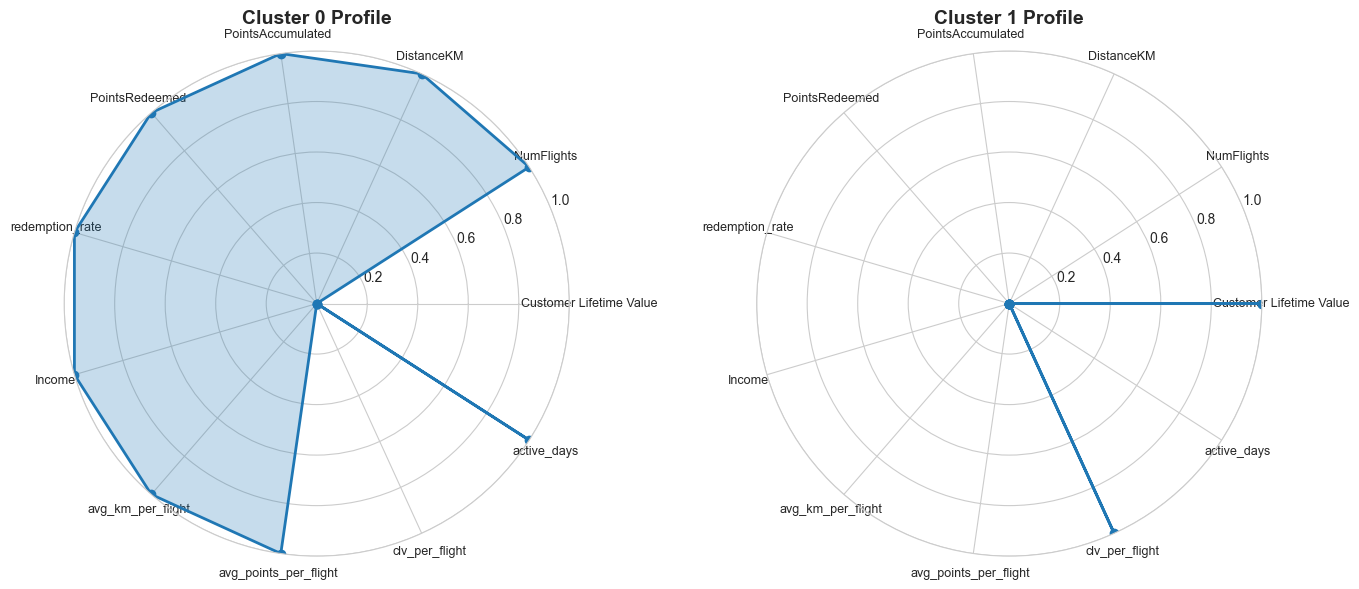

In [29]:
# Create radar charts for each cluster
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6*n_rows), subplot_kw=dict(projection='polar'))
if num_clusters == 1:
    axes = [axes]
elif n_rows == 1 or n_cols == 1:
    axes = axes.flatten()
else:
    axes = axes.flatten()

# Set up the radar chart parameters
categories = list(cluster_profiles_norm.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Create a radar chart for each cluster
for idx, cluster_id in enumerate(cluster_profiles_norm.index):
    ax = axes[idx]
    values = cluster_profiles_norm.loc[cluster_id].values.tolist()
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id} Profile', size=14, fontweight='bold', pad=20)
    ax.grid(True)

# Hide any unused subplots
for idx in range(num_clusters, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f'{output_dir}/cluster_profiles_radar.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Display cluster profiles table
print("=== CLUSTER PROFILES - MEAN VALUES BY FEATURE ===\n")
display(cluster_profiles.round(2))

=== CLUSTER PROFILES - MEAN VALUES BY FEATURE ===



,Customer Lifetime Value,NumFlights,DistanceKM,PointsAccumulated,PointsRedeemed,redemption_rate,Income,avg_km_per_flight,avg_points_per_flight,clv_per_flight,active_days
Hierarchical_Cluster,,,,,,,,,,,
0,7763.54,143.83,291874.03,29181.65,8651.82,29.28,37791.59,1983.56,198.31,500.24,2367.13
1,19737.25,0.03,332.83,33.28,0.00,0.00,35575.39,243.78,24.37,19622.55,1033.55


## 8. Business Segment Naming

Assigning meaningful business names to each cluster based on their profiled characteristics and key differentiators.

In [32]:
# Assign business names to clusters based on their characteristics
# Get the number of unique clusters in the selected algorithm
num_clusters_final = df[selected_algorithm].nunique()

# Create dynamic cluster names based on number of clusters
cluster_names = {}
for i in range(num_clusters_final):
    if i == 0:
        cluster_names[i] = 'VIP Frequent Flyers'
    elif i == 1:
        cluster_names[i] = 'Regular Customers'
    elif i == 2:
        cluster_names[i] = 'Occasional Travelers'
    elif i == 3:
        cluster_names[i] = 'At-Risk/Dormant'
    else:
        cluster_names[i] = f'Segment {i+1}'

df['Segment_Name'] = df[selected_algorithm].map(cluster_names)
df['Final_Cluster'] = df[selected_algorithm]

print(f"=== CUSTOMER SEGMENT DEFINITIONS (Using {overall_best}) ===\n")
for cluster_id in sorted(df[selected_algorithm].unique()):
    name = cluster_names.get(cluster_id, f'Segment {cluster_id+1}')
    count = (df[selected_algorithm] == cluster_id).sum()
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster_id}: {name}")
    print(f"  Size: {count:,} customers ({percentage:.1f}%)")
    print(f"  Characteristics:")
    
    # Display key metrics
    cluster_data = df[df[selected_algorithm] == cluster_id]
    print(f"    - Avg CLV: ${cluster_data['Customer Lifetime Value'].mean():,.2f}")
    print(f"    - Avg Flights: {cluster_data['NumFlights'].mean():.1f}")
    print(f"    - Avg Distance: {cluster_data['DistanceKM'].mean():,.0f} km")
    if 'months_since_flight' in cluster_data.columns:
        print(f"    - Avg Recency: {cluster_data['months_since_flight'].mean():.1f} months")
    print()

=== CUSTOMER SEGMENT DEFINITIONS (Using Hierarchical (Ward)) ===

Cluster 0: VIP Frequent Flyers
  Size: 16,422 customers (98.1%)
  Characteristics:
    - Avg CLV: $7,763.54
    - Avg Flights: 143.8
    - Avg Distance: 291,874 km
    - Avg Recency: 0.0 months

Cluster 1: Regular Customers
  Size: 315 customers (1.9%)
  Characteristics:
    - Avg CLV: $19,737.25
    - Avg Flights: 0.0
    - Avg Distance: 333 km
    - Avg Recency: 0.0 months

